In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [ ]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 7.3 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv("insurance.csv")
df.drop_duplicates(inplace=True)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


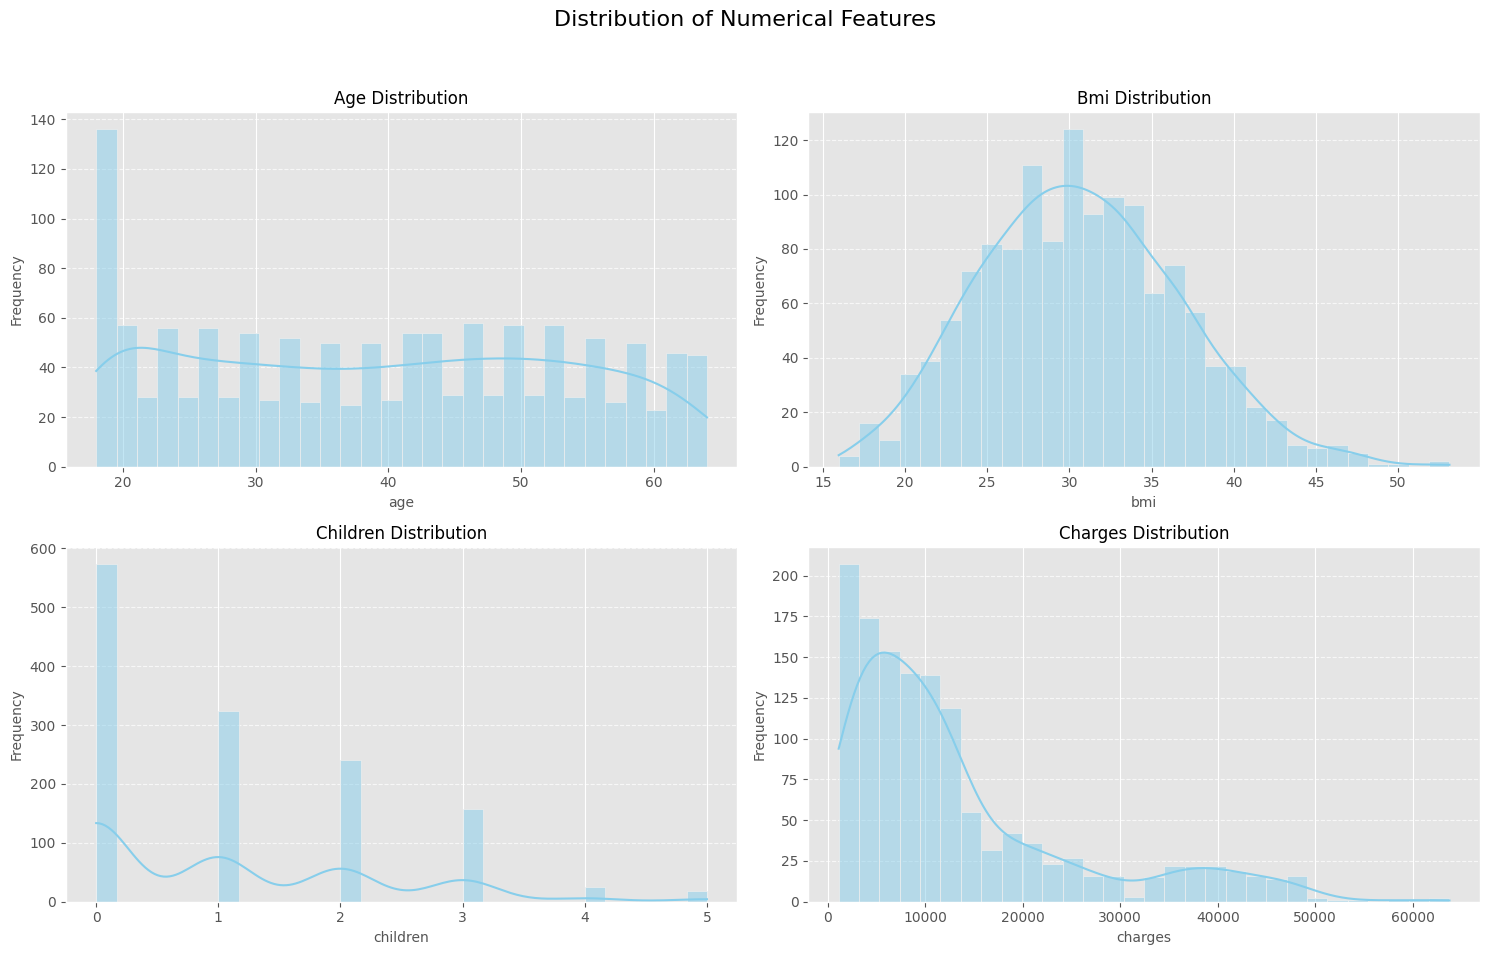

In [ ]:
numerical_features = ['age', 'bmi', 'children', 'charges']


# Plotting numerical features distribution (histograms)
plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Numerical Features', fontsize=16)
for i, col in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1) # 2 rows, 2 columns
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col.capitalize()} Distribution', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

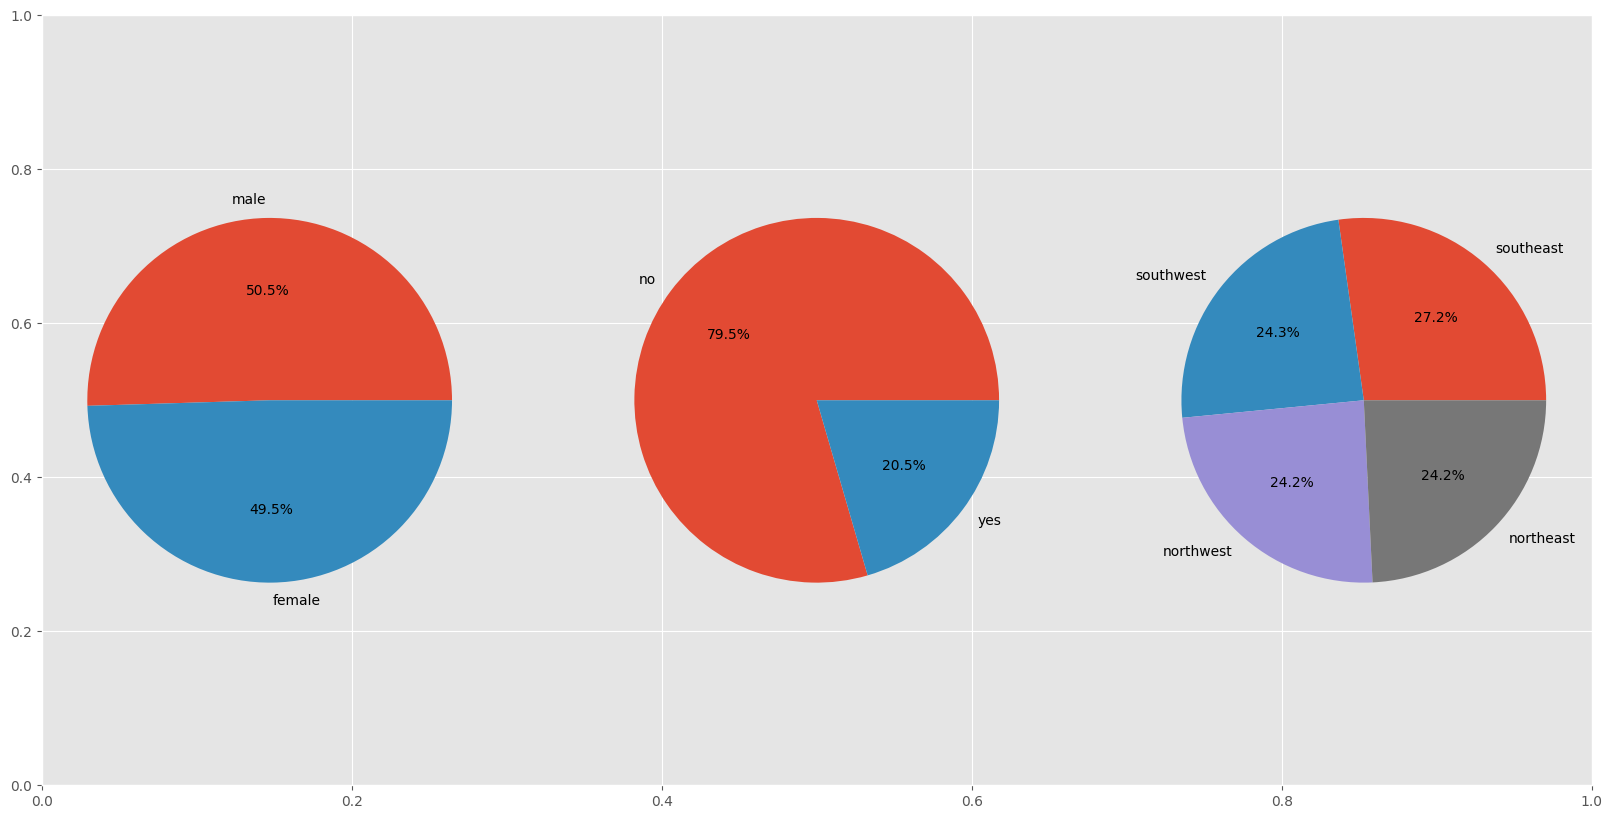

In [ ]:
features = ['sex','smoker', 'region']
plt.subplots(figsize = (20, 10))

for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)

    x = df[col].value_counts()
    plt.pie(x.values, labels = x.index, autopct = "%1.1f%%")

plt.show()

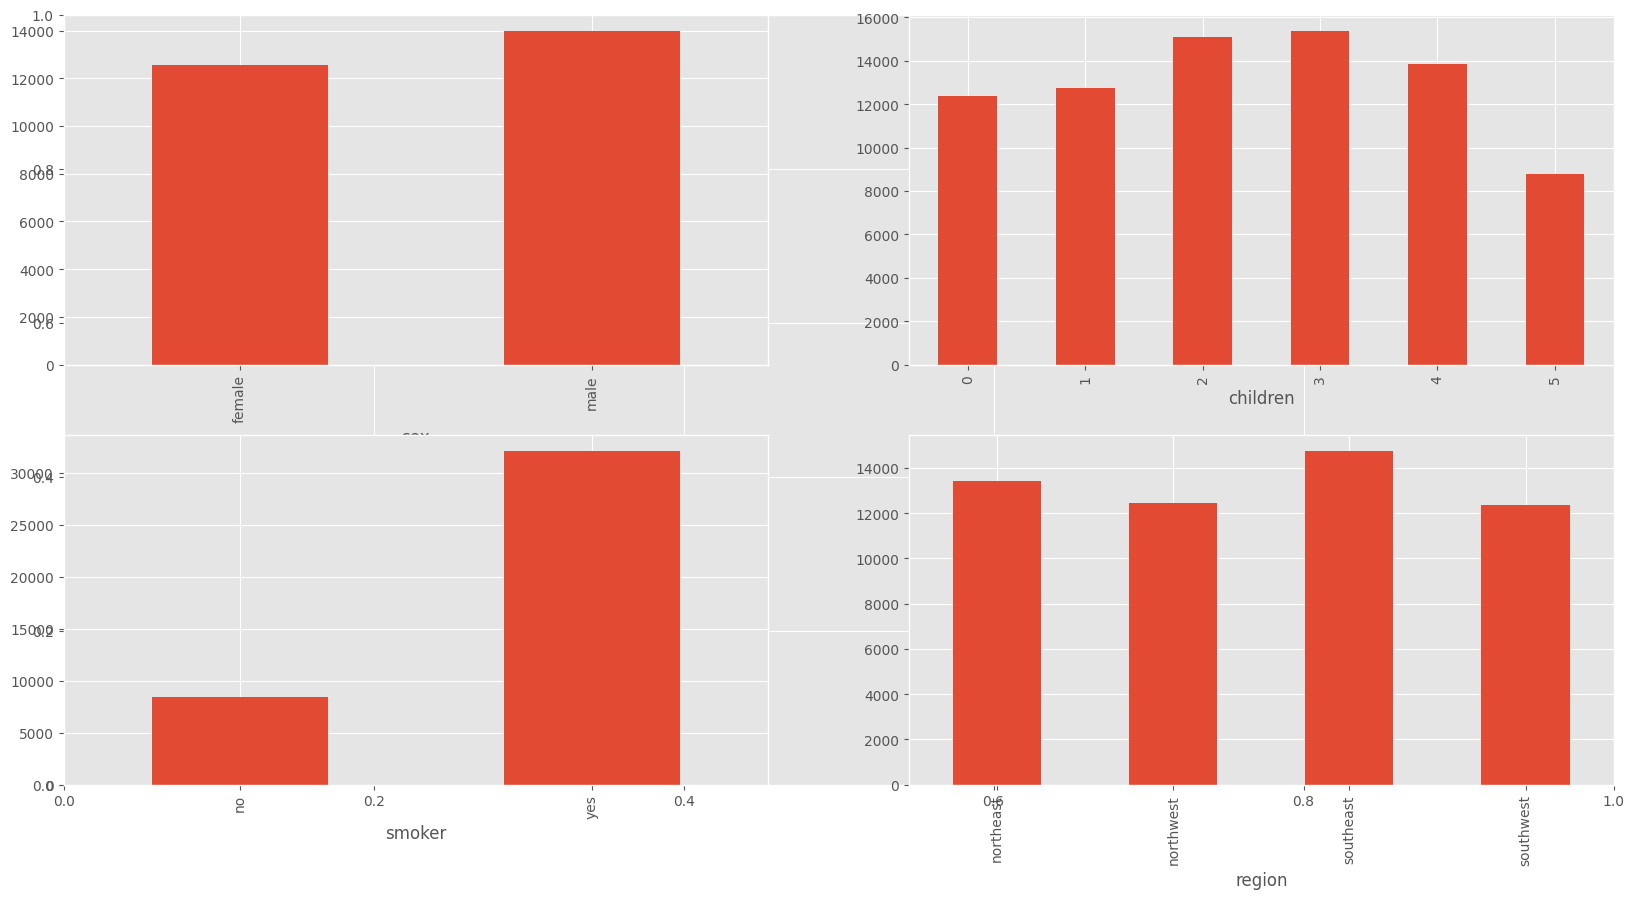

In [ ]:
features = ['sex', 'children', 'smoker', 'region']

plt.subplots(figsize = (20, 10))

for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    df.groupby(col)['charges'].mean().astype(float).plot.bar()
plt.show()

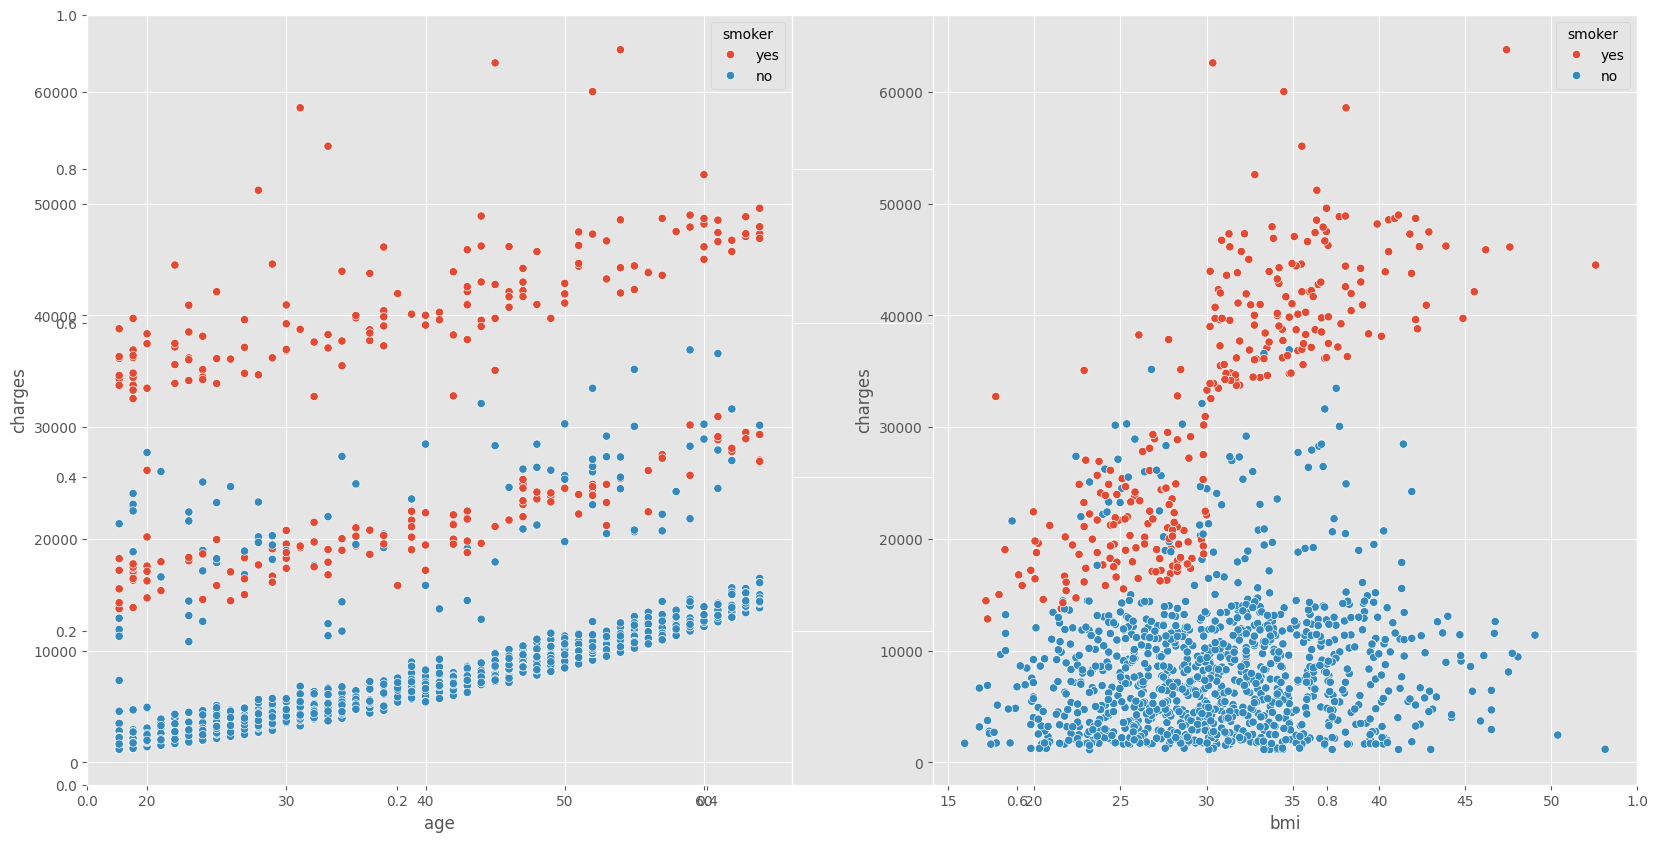

In [ ]:
features = ['age', 'bmi']

plt.subplots(figsize = (20, 10))
for i, col in enumerate(features):
    plt.subplot(1, 2, i + 1)
    sns.scatterplot(data = df, x = col, y = 'charges', hue = 'smoker')
plt.show()

### Feature Distributions (EDA)

In [ ]:
df.drop_duplicates(inplace=True)

<Axes: ylabel='age'>

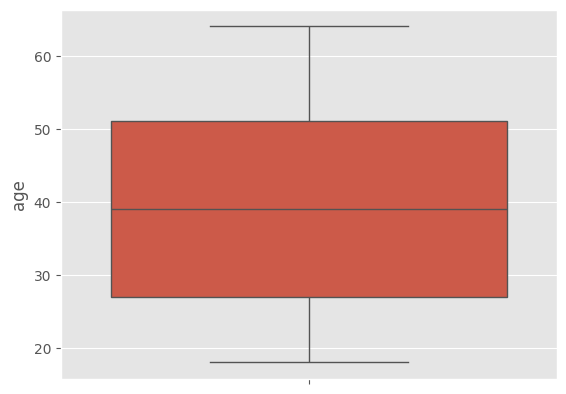

In [ ]:
sns.boxplot(df['age'])

<Axes: ylabel='bmi'>

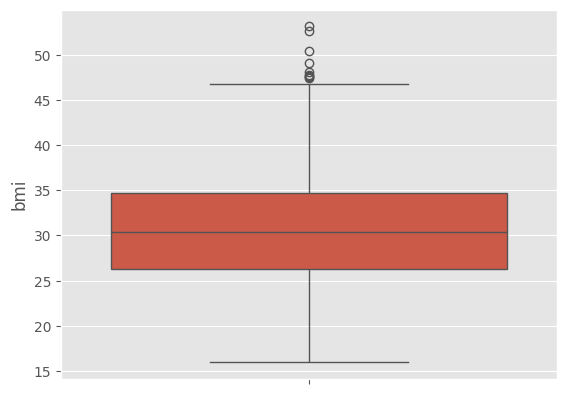

In [ ]:
sns.boxplot(df['bmi'])

In [ ]:
Q1 = df['bmi'].quantile(0.25)
Q2 = df['bmi'].quantile(0.50)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit)
print(upper_limit)

13.674999999999994
47.31500000000001


In [ ]:
from feature_engine.outliers import ArbitraryOutlierCapper
arb = ArbitraryOutlierCapper(min_capping_dict={'bmi': 13.674999999999994}, max_capping_dict = {'bmi': 47.31500000000001})

df[['bmi']] = arb.fit_transform(df[['bmi']])

<Axes: ylabel='bmi'>

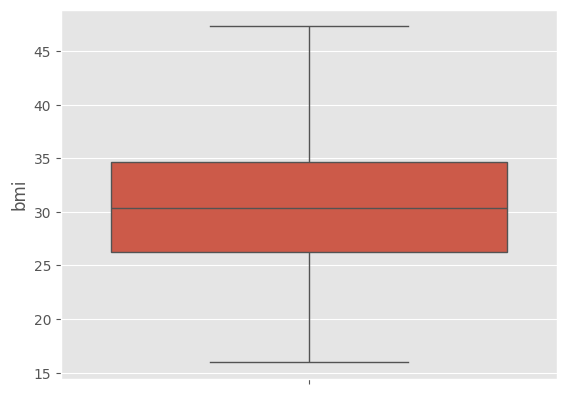

In [ ]:
sns.boxplot(df['bmi'])

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df['bmi'].skew()
df['age'].skew()

np.float64(0.054780773126998195)

In [ ]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [ ]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
df['region'] = df['region'].map({'northwest': 0, 'northeast': 1, 'southwest': 2, 'southeast': 3})

In [ ]:
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,0.019814,0.111998,0.041536,-0.025587,-0.006691,0.298308
sex,0.019814,1.000000,-0.044831,-0.017848,-0.076596,-0.017150,-0.058044
bmi,0.111998,-0.044831,1.000000,0.013692,0.003151,0.261154,0.199063
children,0.041536,-0.017848,0.013692,1.000000,0.007331,-0.020206,0.067389
smoker,-0.025587,-0.076596,0.003151,0.007331,1.000000,0.053454,0.787234
region,-0.006691,-0.017150,0.261154,-0.020206,0.053454,1.000000,0.056070
charges,0.298308,-0.058044,0.199063,0.067389,0.787234,0.056070,1.000000


In [ ]:
X = df.drop(['charges'], axis = 1)
y = df['charges']

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

In [ ]:
l1 = []
l2 = []
l3=  []
cvs = 0
for i in range(40, 50):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = i)
    lrmodel = LinearRegression()
    lrmodel.fit(X_train, y_train)
    l1.append(lrmodel.score(X_train, y_train))
    l2.append(lrmodel.score(X_test, y_test))
    cvs = (cross_val_score(lrmodel, X, y, cv=5)).mean()
    l3.append(cvs)
    df1 = pd.DataFrame({'train_acc': l1, 'test_acc': l2, 'cvs': l3})

In [ ]:
df1

,train_acc,test_acc,cvs
0,0.741539,0.779138,0.747
1,0.756756,0.704260,0.747
2,0.729648,0.806362,0.747
3,0.753997,0.734113,0.747
4,0.742804,0.780840,0.747
5,0.753137,0.732727,0.747
6,0.741612,0.775969,0.747
7,0.732525,0.794691,0.747
8,0.751989,0.741911,0.747
9,0.756583,0.721869,0.747


**MODEL EVALUATION**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
lrmodel = LinearRegression()
lrmodel.fit(X_train, y_train)
print(lrmodel.score(X_train, y_train))
print(lrmodel.score(X_test, y_test))
print(cross_val_score(lrmodel, X, y, cv=5).mean())

0.7296475807576607
0.8063624710782457
0.7469996197062543


In [ ]:
from sklearn.metrics import r2_score
svrmodel = SVR()
svrmodel.fit(X_train, y_train)
ypredtrain1 = svrmodel.predict(X_train)
ypredtest1 = svrmodel.predict(X_test)

In [ ]:
print(r2_score(y_train, ypredtrain1))
print(r2_score(y_test, ypredtest1))
print(cross_val_score(svrmodel, X, y, cv=5).mean())

-0.1015150418030557
-0.13444586959905647
-0.10374692104571026


In [ ]:
rfmodel  = RandomForestRegressor(random_state = 42)
rfmodel.fit(X_train, y_train)
ypredtrain2 = rfmodel.predict(X_train)
ypredtest2 = rfmodel.predict(X_test)
print(r2_score(y_train, ypredtrain2))
print(r2_score(y_test, ypredtest2))
print(cross_val_score(rfmodel, X, y, cv=5).mean())

0.9739337992698777
0.8797402284668216
0.8368492823523981


In [ ]:
from sklearn.model_selection import GridSearchCV
estimator = RandomForestRegressor(random_state = 42)
param_grid = {'n_estimators': [10, 40, 50, 98, 100,  120, 150]}
grid = GridSearchCV(estimator, param_grid, scoring = "r2", cv = 5)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'n_estimators': 98}


In [ ]:
rfmodel = RandomForestRegressor(random_state = 42, n_estimators = 98)
rfmodel.fit(X_train, y_train)
ypredtrain2 = rfmodel.predict(X_train)
ypredtest2 = rfmodel.predict(X_test)
print(r2_score(y_train, ypredtrain2))
print(r2_score(y_test, ypredtest2))
print(cross_val_score(rfmodel, X, y, cv=5).mean())

0.9737482927504374
0.8800648670590465
0.8366462352498589


In [ ]:
from sklearn.model_selection import GridSearchCV
estimator=GradientBoostingRegressor()
param_grid={'n_estimators':[10,15,19,20,21,50],'learning_rate':[0.1,0.19,0.2,0.21,0.8,1]}
grid=GridSearchCV(estimator,param_grid,scoring="r2",cv=5)
grid.fit(X_train,y_train)
print(grid.best_params_)
gbmodel=GradientBoostingRegressor(n_estimators=19,learning_rate=0.2)
gbmodel.fit(X_train,y_train)
ypredtrain3=gbmodel.predict(X_train)
ypredtest3=gbmodel.predict(X_test)
print(r2_score(y_train,ypredtrain3))
print(r2_score(y_test,ypredtest3))
print(cross_val_score(gbmodel,X,y,cv=5,).mean())

{'learning_rate': 0.2, 'n_estimators': 20}
0.8682397447116927
0.9017109716082662
0.8606660830850504


In [ ]:
xgmodel=XGBRegressor()
xgmodel.fit(X_train,y_train)
ypredtrain4=xgmodel.predict(X_train)
ypredtest4=xgmodel.predict(X_test)
print(r2_score(y_train,ypredtrain4))
print(r2_score(y_test,ypredtest4))
print(cross_val_score(xgmodel,X,y,cv=5,).mean())

0.9954190871352122
0.8574210053330951
0.8080768178656615


In [ ]:
from sklearn.model_selection import GridSearchCV
estimator=XGBRegressor()
param_grid={'n_estimators':[10,15,20,40,50],'max_depth':[3,4,5],'gamma':[0,0.15,0.3,0.5,1]}
grid=GridSearchCV(estimator,param_grid,scoring="r2",cv=5)
grid.fit(X_train,y_train)
print(grid.best_params_)
xgmodel=XGBRegressor(n_estimators=15,max_depth=3,gamma=0)
xgmodel.fit(X_train,y_train)
ypredtrain4=xgmodel.predict(X_train)
ypredtest4=xgmodel.predict(X_test)
print(r2_score(y_train,ypredtrain4))
print(r2_score(y_test,ypredtest4))
print(cross_val_score(xgmodel,X,y,cv=5,).mean())

{'gamma': 0, 'max_depth': 3, 'n_estimators': 10}
0.8700755731767518
0.9024454317124272
0.8605811160326914


In [ ]:
features_important = pd.DataFrame(data = grid.best_estimator_.feature_importances_, index = X.columns,
                     columns = ['Importance'])

In [ ]:
features_important

,Importance
age,0.038633
sex,0.000000
bmi,0.133449
children,0.011073
smoker,0.809626
region,0.007219


In [ ]:
important_features = features_important[features_important['Importance'] > 0.01]

In [ ]:
important_features

,Importance
age,0.038633
bmi,0.133449
children,0.011073
smoker,0.809626


In [ ]:
Xf = df.drop(['sex', 'region', 'charges'], axis = 1)
# Ensure X is updated to reflect the new feature set for model training
X = Xf.copy()

X_train, X_test, y_train, y_test = train_test_split(Xf, y, test_size = 0.2, random_state = 42)

In [ ]:
finalmodel=XGBRegressor(n_estimators=15,max_depth=3,gamma=0)
finalmodel.fit(X_train,y_train)
ypredtrain4=finalmodel.predict(X_train)
ypredtest4=finalmodel.predict(X_test)
print(r2_score(y_train,ypredtrain4))
print(r2_score(y_test,ypredtest4))
print(cross_val_score(finalmodel,X,y,cv=5,).mean())

0.869105118970057
0.9007425513499979
0.8606266871712276


In [ ]:
import pickle
pickle.dump(finalmodel, open("model.pkl", "wb"))

In [ ]:
new_data=pd.DataFrame({'age':19,'sex':'female','bmi':25.9,'children':3,'smoker':'no','region':'northeast'},index=[0])
new_data['smoker']=new_data['smoker'].map({'yes':1,'no':0})
new_data=new_data.drop(new_data[['sex','region']],axis=1)
finalmodel.predict(new_data)

array([6379.257], dtype=float32)

---
# Model Comparison — Linear, Ridge, Random Forest, Gradient Boosting, XGBoost
We evaluate **5 models** across 6 metrics:

| Metric | What it tells you |
|--------|-------------------|
| Train R² | Fit on training data |
| Test R²  | Generalisation (most important) |
| CV R²    | 5-fold cross-val (least biased) |
| MAE      | Average dollar error |
| RMSE     | Penalises large errors more |
| Overfit  | Train R² − Test R² (lower = better) |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# ── Define the 5 models ───────────────────────────────────────────────────
compare_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(random_state=42, n_estimators=98),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=19, learning_rate=0.2),
    'XGBoost':           XGBRegressor(n_estimators=15, max_depth=3, gamma=0, verbosity=0),
}

records, preds_dict = [], {}
for name, model in compare_models.items():
    model.fit(X_train, y_train)
    ytr = model.predict(X_train)
    yte = model.predict(X_test)
    cv  = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    preds_dict[name] = yte
    records.append({
        'Model':    name,
        'Train R²': round(r2_score(y_train, ytr), 4),
        'Test R²':  round(r2_score(y_test,  yte), 4),
        'CV R²':    round(cv, 4),
        'MAE ($)':  round(mean_absolute_error(y_test, yte), 1),
        'RMSE ($)': round(np.sqrt(mean_squared_error(y_test, yte)), 1),
        'Overfit':  round(r2_score(y_train, ytr) - r2_score(y_test, yte), 4),
    })

df_cmp = pd.DataFrame(records).set_index('Model')

# Pretty-print with highlighting
styled = df_cmp.style \
    .background_gradient(subset=['Test R²','CV R²'], cmap='Greens') \
    .background_gradient(subset=['MAE ($)','RMSE ($)','Overfit'], cmap='Reds_r') \
    .format({
        'Train R²': '{:.4f}', 'Test R²': '{:.4f}', 'CV R²': '{:.4f}',
        'MAE ($)': '${:,.1f}', 'RMSE ($)': '${:,.1f}', 'Overfit': '{:.4f}'
    })
display(styled)

,Train R²,Test R²,CV R²,MAE ($),RMSE ($),Overfit
Model,,,,,,
Linear Regression,0.7293,0.8047,0.7469,"$4,203.2","$5,990.9",-0.0754
Ridge Regression,0.7293,0.8037,0.7469,"$4,220.0","$6,005.3",-0.0745
Random Forest,0.9722,0.8720,0.8252,"$2,689.5","$4,849.2",0.1002
Gradient Boosting,0.8677,0.8998,0.8598,"$2,514.0","$4,290.1",-0.0322
XGBoost,0.8691,0.9007,0.8606,"$2,493.1","$4,270.7",-0.0316


### Plot 1 — R² Scores: Train vs Test vs CV

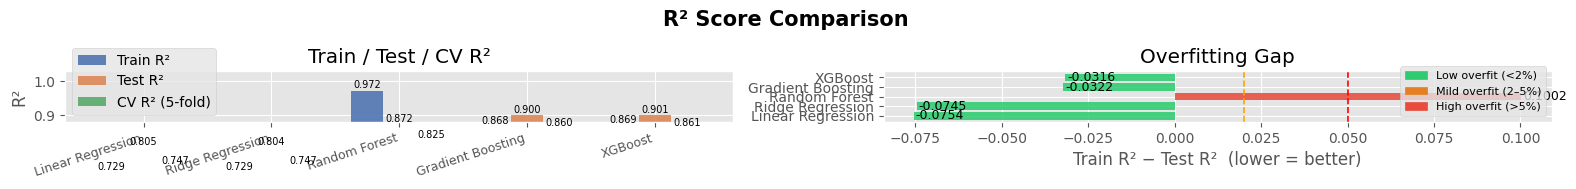

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('R² Score Comparison', fontsize=15, fontweight='bold')

# Grouped bar
x, w = np.arange(len(df_cmp)), 0.25
ax = axes[0]
b1 = ax.bar(x - w,  df_cmp['Train R²'], w, label='Train R²',       color='#4C72B0', alpha=0.88)
b2 = ax.bar(x,      df_cmp['Test R²'],  w, label='Test R²',        color='#DD8452', alpha=0.88)
b3 = ax.bar(x + w,  df_cmp['CV R²'],    w, label='CV R² (5-fold)', color='#55A868', alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels(df_cmp.index, rotation=18, ha='right', fontsize=9)
ax.set_ylabel('R²')
ax.set_title('Train / Test / CV R²')
ax.set_ylim(0.88, 1.03)
ax.legend()
for grp in [b1, b2, b3]:
    for rect in grp:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.001,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

# Overfit gap
ax2 = axes[1]
colors = ['#2ecc71' if v < 0.02 else '#e67e22' if v < 0.05 else '#e74c3c'
          for v in df_cmp['Overfit']]
bars = ax2.barh(df_cmp.index, df_cmp['Overfit'], color=colors, alpha=0.88)
ax2.set_xlabel('Train R² − Test R²  (lower = better)')
ax2.set_title('Overfitting Gap')
ax2.axvline(0.02, color='orange', ls='--', lw=1.2, label='2% threshold')
ax2.axvline(0.05, color='red',    ls='--', lw=1.2, label='5% threshold')
ax2.legend(fontsize=8)
for bar, val in zip(bars, df_cmp['Overfit']):
    ax2.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
green_p  = mpatches.Patch(color='#2ecc71',  label='Low overfit (<2%)')
orange_p = mpatches.Patch(color='#e67e22',  label='Mild overfit (2–5%)')
red_p    = mpatches.Patch(color='#e74c3c',  label='High overfit (>5%)')
ax2.legend(handles=[green_p, orange_p, red_p], fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

### Plot 2 — MAE & RMSE (dollar errors on test set)

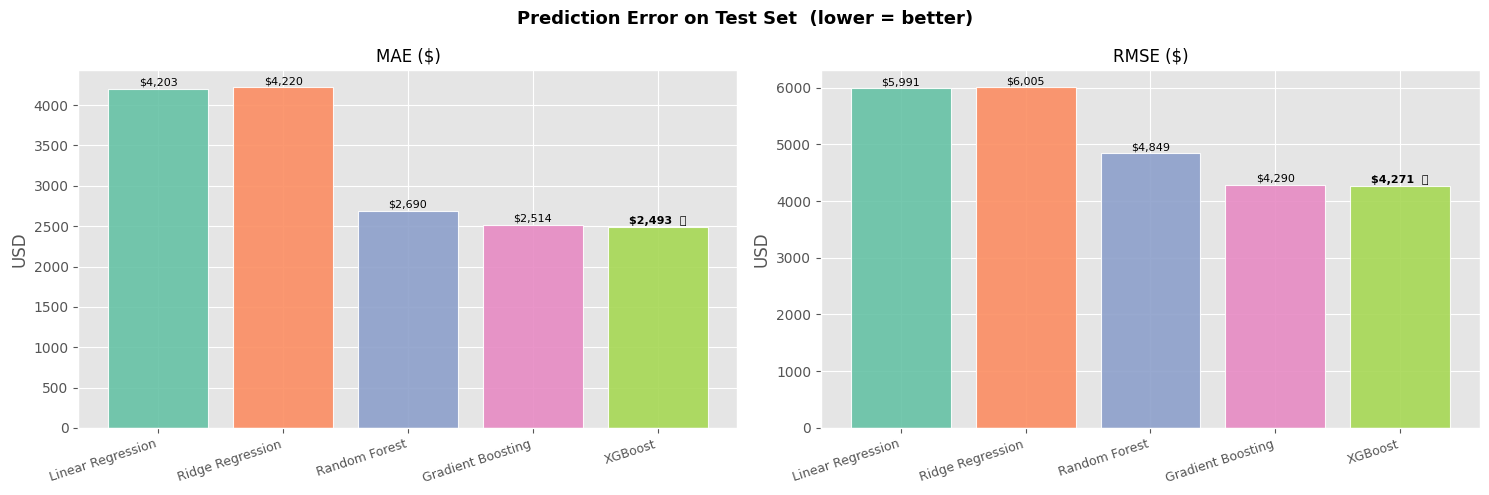

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Prediction Error on Test Set  (lower = better)', fontsize=13, fontweight='bold')
palette = sns.color_palette('Set2', len(df_cmp))

for ax, metric in zip(axes, ['MAE ($)', 'RMSE ($)']):
    bars = ax.bar(df_cmp.index, df_cmp[metric], color=palette, alpha=0.9, edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel('USD')
    ax.set_xticklabels(df_cmp.index, rotation=18, ha='right', fontsize=9)
    best = df_cmp[metric].idxmin()
    for bar, name in zip(bars, df_cmp.index):
        h = bar.get_height()
        label = f'${h:,.0f}' + ('  ⭐' if name == best else '')
        ax.text(bar.get_x() + bar.get_width()/2, h + 15, label,
                ha='center', va='bottom', fontsize=8,
                fontweight='bold' if name == best else 'normal')

plt.tight_layout()
plt.show()

### Plot 3 — Actual vs Predicted (test set scatter)

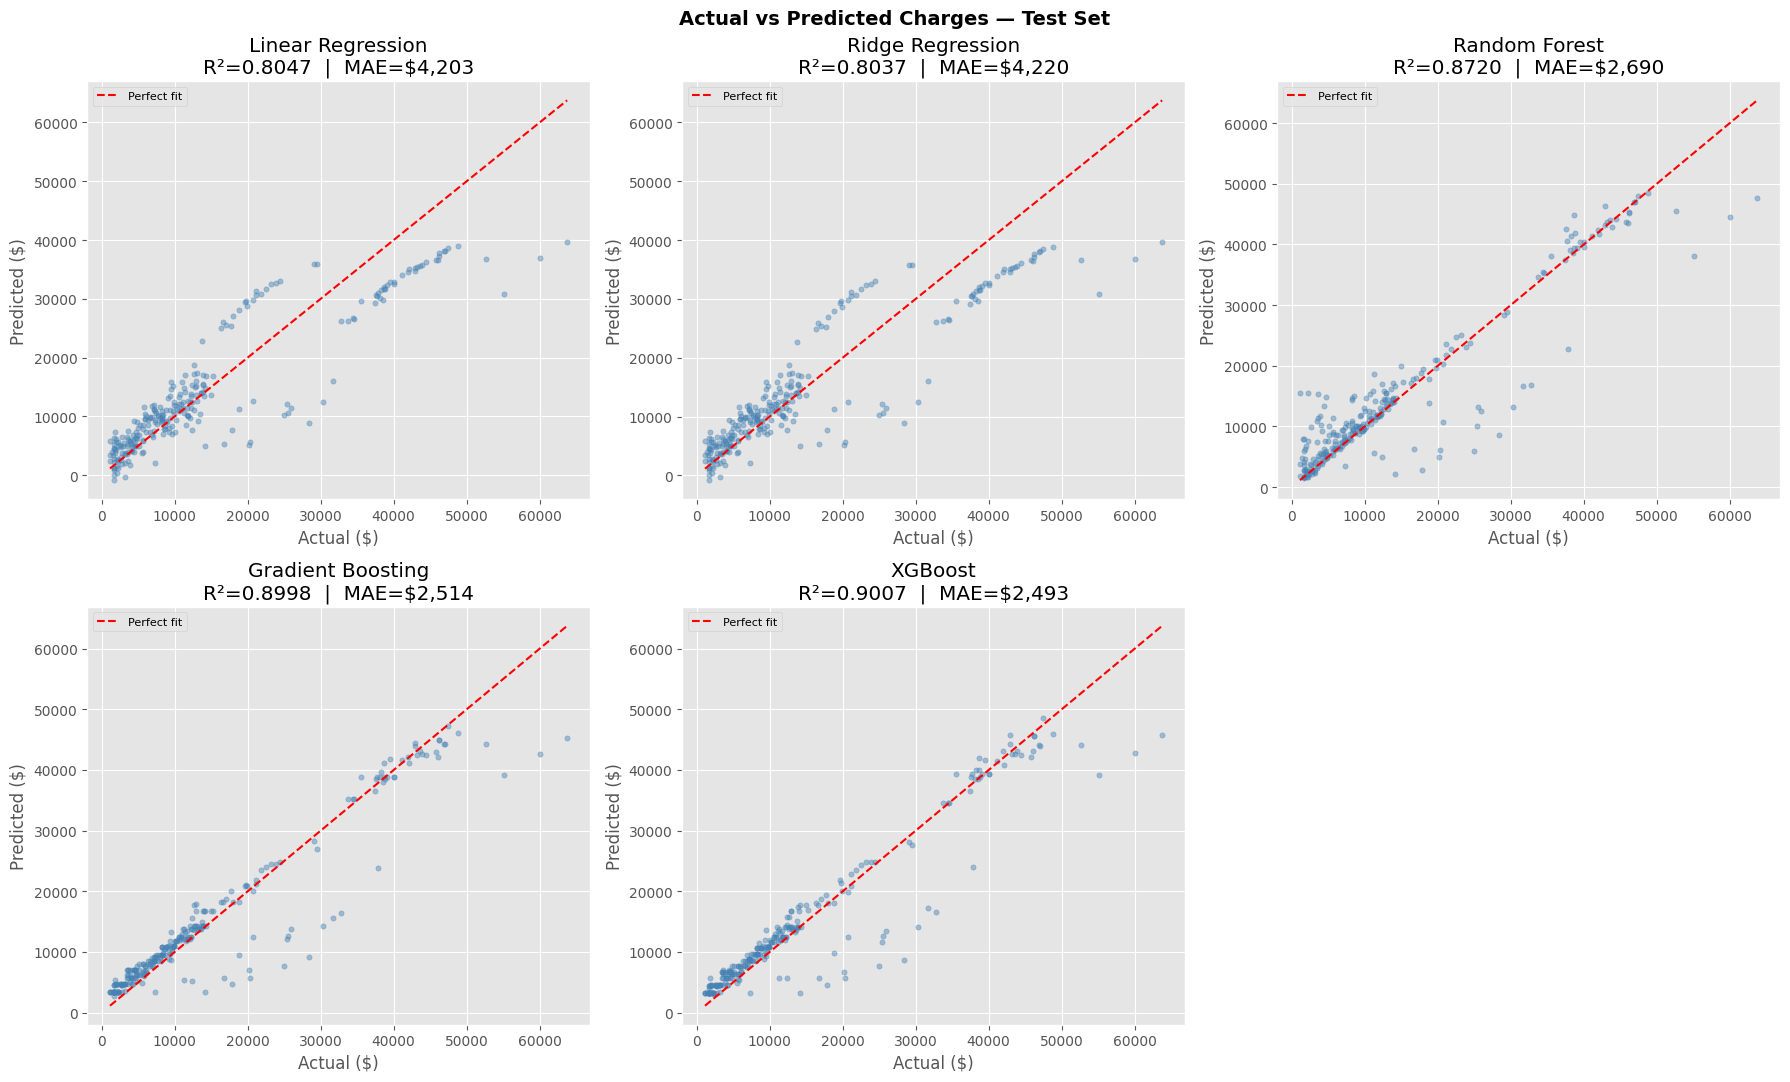

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Actual vs Predicted Charges — Test Set', fontsize=14, fontweight='bold')
axes = axes.flatten()
y_min, y_max = float(y_test.min()), float(y_test.max())

for ax, (name, ypred) in zip(axes, preds_dict.items()):
    r2  = r2_score(y_test, ypred)
    mae = mean_absolute_error(y_test, ypred)
    ax.scatter(y_test, ypred, alpha=0.45, s=14, color='steelblue')
    ax.plot([y_min, y_max], [y_min, y_max], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual ($)')
    ax.set_ylabel('Predicted ($)')
    ax.set_title(f'{name}\nR²={r2:.4f}  |  MAE=${mae:,.0f}')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### Plot 4 — Residual Distributions (errors should be centred at 0)

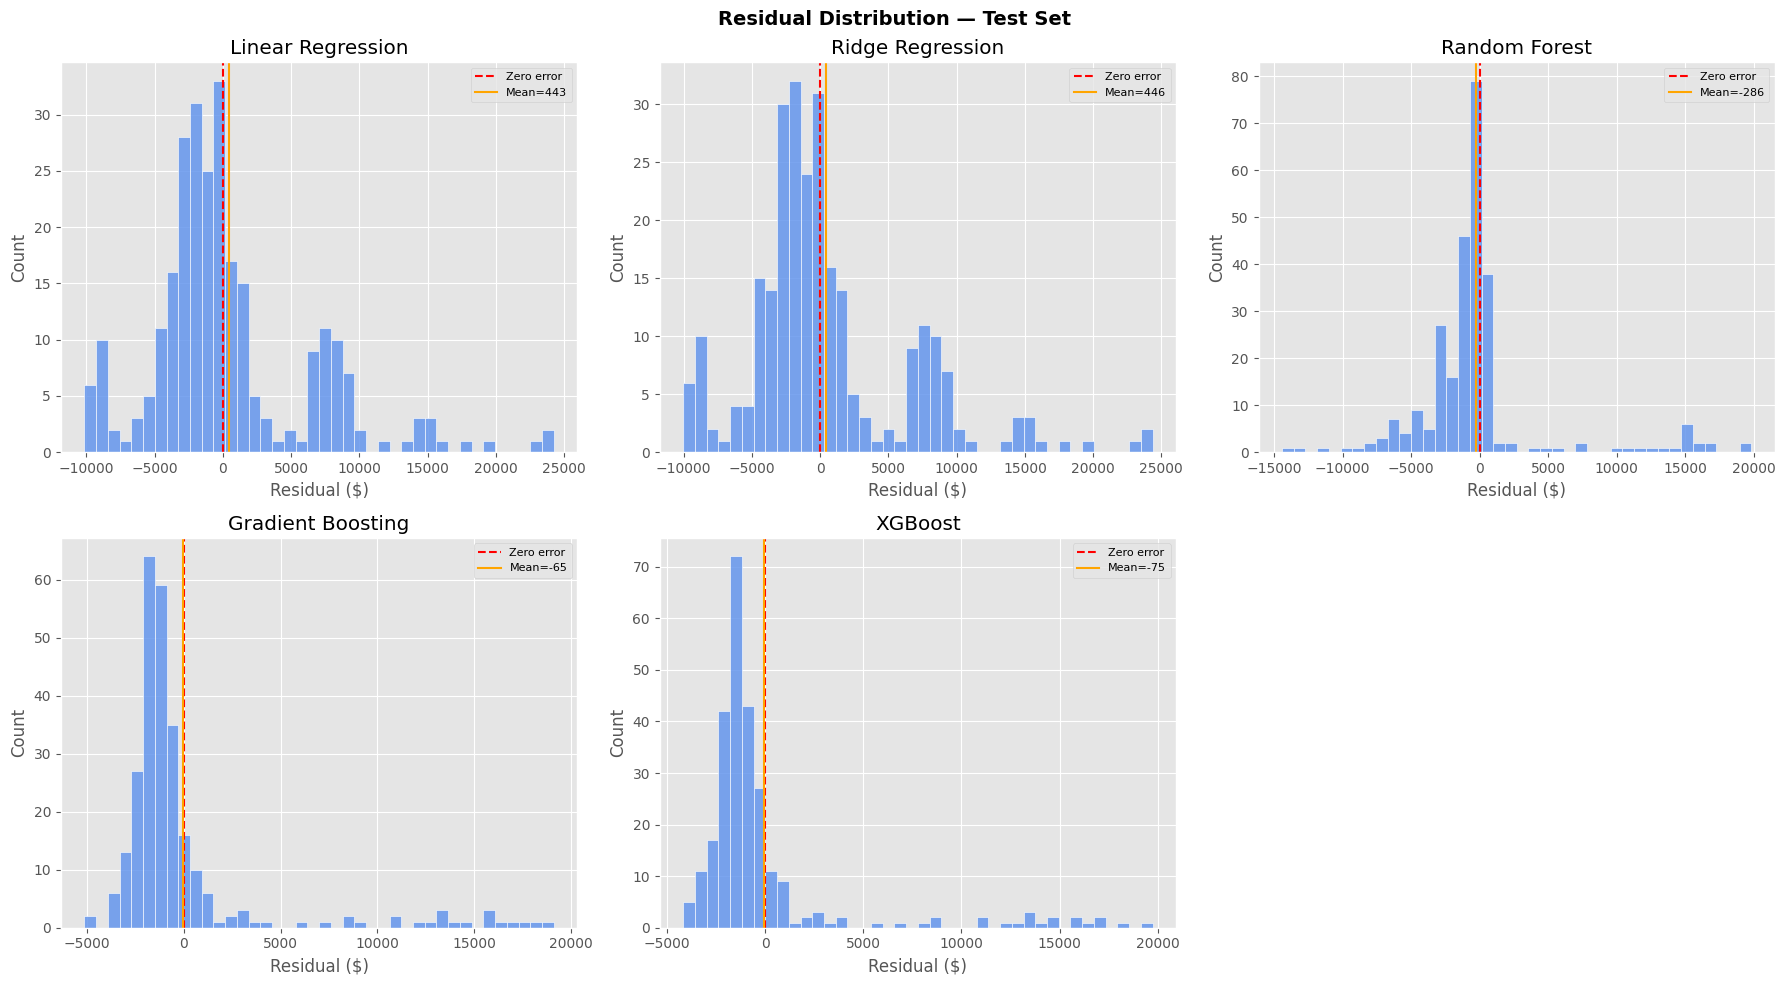

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Residual Distribution — Test Set', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (name, ypred) in zip(axes, preds_dict.items()):
    res = np.array(y_test).ravel() - np.array(ypred).ravel()

    ax.hist(res, bins=40, color='cornflowerblue', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', lw=1.5, ls='--', label='Zero error')
    ax.axvline(res.mean(), color='orange', lw=1.5, label=f'Mean={res.mean():,.0f}')

    ax.set_title(name)
    ax.set_xlabel('Residual ($)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### Plot 5 — Normalised Performance Heatmap

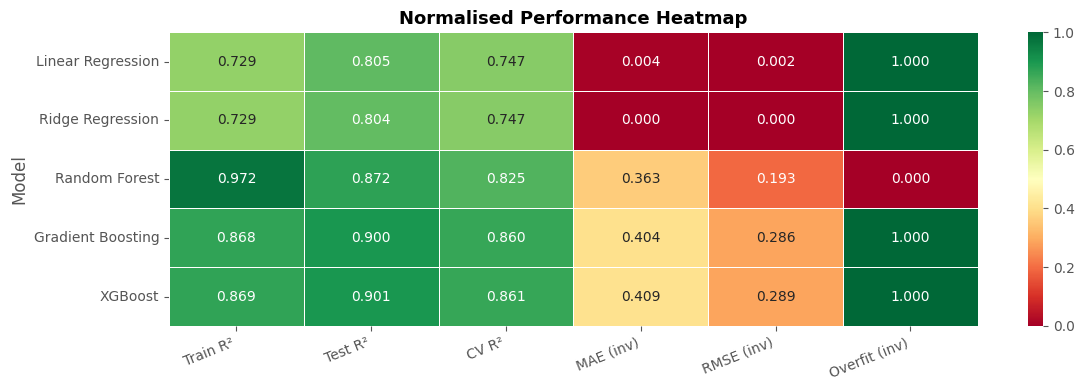

  Best Test R²   : XGBoost  (0.9007)
  Best CV R²     : XGBoost  (0.8606)
  Lowest MAE     : XGBoost  (2493.1)
  Lowest RMSE    : XGBoost  (4270.7)
  Least Overfit  : Linear Regression  (-0.0754)


In [ ]:
hm = df_cmp[['Train R²','Test R²','CV R²']].copy()
hm['MAE (inv)']  = 1 - (df_cmp['MAE ($)']  / df_cmp['MAE ($)'].max())
hm['RMSE (inv)'] = 1 - (df_cmp['RMSE ($)'] / df_cmp['RMSE ($)'].max())
hm['Overfit (inv)'] = 1 - (df_cmp['Overfit'].clip(lower=0) / df_cmp['Overfit'].clip(lower=0).max())

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(hm.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.6, ax=ax, vmin=0, vmax=1, annot_kws={'size': 10})
ax.set_title('Normalised Performance Heatmap', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=22, ha='right')
plt.tight_layout()
plt.show()


for metric, label, best_fn in [
    ('Test R²',  'Best Test R²',  'idxmax'),
    ('CV R²',    'Best CV R²',    'idxmax'),
    ('MAE ($)',  'Lowest MAE',    'idxmin'),
    ('RMSE ($)', 'Lowest RMSE',   'idxmin'),
    ('Overfit',  'Least Overfit', 'idxmin'),
]:
    winner = getattr(df_cmp[metric], best_fn)()
    val    = df_cmp.loc[winner, metric]
    print(f'  {label:<15}: {winner}  ({val})')


In [ ]:
import pandas as pd
from IPython.display import display

metrics_map = [
    ('Best Test R²',   'Test R²',  'idxmax', lambda v: f'{v:.4f}', 'Best generalisation on unseen data'),
    ('Best CV R²',     'CV R²',    'idxmax', lambda v: f'{v:.4f}', 'Most reliable across all CV folds'),
    ('Lowest MAE',     'MAE ($)',  'idxmin', lambda v: f'${v:,.0f}', 'Lowest average dollar error'),
    ('Lowest RMSE',    'RMSE ($)', 'idxmin', lambda v: f'${v:,.0f}', 'Fewest large prediction errors'),
    ('Least Overfit',  'Overfit',  'idxmin', lambda v: f'{v:.4f}', 'Train−Test gap smallest'),
]

rows = []
for metric_label, col, fn, fmt, remark in metrics_map:
    winner = getattr(df_cmp[col], fn)()
    value  = fmt(df_cmp.loc[winner, col])
    rows.append({'Metric': metric_label, 'Winner': winner, 'Value': value, 'Remark': remark})

df_summary = pd.DataFrame(rows)

def highlight_winner(col):
    colors = []
    for v in col:
        if 'Gradient Boosting' in v:
            colors.append('background-color:#e8f5e9;font-weight:600;color:#1b5e20')
        elif 'XGBoost' in v:
            colors.append('background-color:#e8eaf6;font-weight:600;color:#1a237e')
        elif 'Ridge' in v:
            colors.append('background-color:#fff8e1;font-weight:600;color:#e65100')
        elif 'Linear' in v:
            colors.append('background-color:#fce4ec;font-weight:600;color:#880e4f')
        elif 'Random' in v:
            colors.append('background-color:#f3e5f5;font-weight:600;color:#4a148c')
        else:
            colors.append('')
    return colors

styled = (
    df_summary.style
    .set_caption('Overall Model Comparison — Best Model Per Metric')
    .apply(highlight_winner, subset=['Winner'])
    .set_properties(**{'text-align':'left','font-size':'13px','padding':'8px 14px'})
    .set_table_styles([
        {'selector':'caption','props':[('font-size','15px'),('font-weight','700'),('padding','10px 0'),('text-align','left')]},
        {'selector':'th','props':[('background-color','#f5f5f5'),('font-size','13px'),('padding','8px 14px')]},
    ])
    .hide(axis='index')
)
display(styled)


from collections import Counter
winners = [r['Winner'] for r in rows]
counts  = Counter(winners)
top     = counts.most_common(1)[0]

print('\n' + ' Overall Verdict '.center(60,'═'))
print(f'  {top[0]} wins {top[1]} of {len(rows)} metrics — best balanced model.')
for model, count in counts.most_common()[1:]:
    print(f'  {model} wins {count} metric(s).')
print('═'*60)

Metric,Winner,Value,Remark
Best Test R²,XGBoost,0.9007,Best generalisation on unseen data
Best CV R²,XGBoost,0.8606,Most reliable across all CV folds
Lowest MAE,XGBoost,"$2,493",Lowest average dollar error
Lowest RMSE,XGBoost,"$4,271",Fewest large prediction errors
Least Overfit,Linear Regression,-0.0754,Train−Test gap smallest



═════════════════════ Overall Verdict ══════════════════════
  XGBoost wins 4 of 5 metrics — best balanced model.
  Linear Regression wins 1 metric(s).
════════════════════════════════════════════════════════════
